## Libraries & Function

In [1]:
%matplotlib ipympl
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt
from qutip import *
from IPython.display import Image, display, Math

In [2]:
#funzione per plottare in LaTex delle matrici
def array_to_latex(array, real = False, array_name = None):
    array = array.real if real else array
    matrix = ''
    for row in array:
        try:
            for number in row:
                matrix += f'{number}&'
        except TypeError:
            matrix += f'{row}&'
        matrix = matrix[:-1] + r'\\'
    if array_name != None:
        display(Math(array_name+r' = \begin{bmatrix}'+matrix+r'\end{bmatrix}'))
    else:
        display(Math(r'\begin{bmatrix}'+matrix+r'\end{bmatrix}'))

### Lindblad functions

In [3]:
 def Liouvillian(H, gamma_k, L_k):
    
     I = np.eye(H.shape[0])  #creo matrice identità delle diemnsioni adatte
     super_L = -1.j * (np.kron(I, H) - np.kron(H.T, I))  #Dissipatore di Lindblad
    
     for k in range(len(gamma_k)):
        super_L += gamma_k[k] * (np.kron(np.conj(L_k[k]), L_k[k]) - 0.5 * np.kron(I, np.conj(L_k[k]).T @ L_k[k]) - 0.5 * np.kron((np.conj(L_k[k]).T @ L_k[k]).T, I))

     return super_L


In [4]:
def Lindblad_evo(rho, H, gamma_k, L_k, times, method="expm", vectorized=True):
    """
    Evolution of the density matrux with the Linblad Eq.
    
    Method: "U" -> propagator = expm(super_L * dt) (needs L_k as NumPy array)
            "diagonal" -> diagonalizzation of the super-op. (needs L_k as NumPy array )
            "qutip" -> using mesolve from QuTiP (needs L_k as Qobj)
    Vectorized: True/False to choose the output format
    
    Output:
            - if vectorized=True → array (N^2, Nt)
            - if vectorized=False → array (Nt, N_site, N_site)
       
    """
    N_shape = H.shape[0]
    dt = times[1] - times[0]
    
    # ===============================
    #   EXPM & DIAGONAL METHODS
    # ===============================
    if method in ["expm", "diagonal"]:
        # Converts Qobj in NumPy array 
        L_k_num = [L.full() if hasattr(L, "full") else np.array(L) for L in L_k]
        H_num = H.full() if hasattr(H, "full") else np.array(H)
        rho_num = rho.full() if hasattr(rho, "full") else np.array(rho)
        
        # Build up of the Lindbladian
        super_L = Liouvillian(H_num, gamma_k, L_k_num)
        
        # Vectorized intial state
        rho_vec = rho_num.reshape(N_shape*N_shape)
        
        # Result array inizialized
        rho_vec_list = np.zeros((N_shape*N_shape, len(times)), dtype=complex)
        rho_vec_list[:, 0] = rho_vec
        
        # Time Propagator
        if method == "expm":
            super_U = expm(super_L * dt)
            
            # Evolution
            for i in range(1, len(times)):
                rho_vec_list[:, i] = super_U @ rho_vec_list[:, i - 1]
            
            # Output
            if vectorized:
                return rho_vec_list  # (N_shape^2, Nt)
            else:
                return rho_vec_list.T.reshape(len(times), N_shape, N_shape)  # (Nt, N_shape, N_shape)
                
        elif method == "diagonal":             #carefull, dt could be not homogneous, so calculate it in every loop in i
            #Diagobalization of the Super-Op.
            W, V = np.linalg.eig(super_L)
            Vinv = np.linalg.inv(V)
            # Converts in NumPy array
            W = np.array(W)  #Eigenenergies
            V = np.array(V)  #Eigenvectors
            Vinv = np.array(Vinv)
            
            # Build up of the Diagonal Lindbladian
            U_diag = np.diag(np.exp(W * dt))
            super_U = U_diag

            # Initial state in diagonal basis
            rho_vec_list_diagonal = np.zeros((rho_vec_list.shape[0], len(times)), dtype=complex)
            rho_vec_list_diagonal[:, 0] = Vinv @ rho_vec_list[:, 0]
            
            # Evolution
            for i in range(1, len(times)):
                rho_vec_list_diagonal[:, i] = super_U @ rho_vec_list_diagonal[:, i - 1]

                rho_vec_list[:, i] = V @ rho_vec_list_diagonal[:, i]
                
            # Output with Eigenenergies & Eigenvectors (as NumPy array)
            if vectorized:
                return rho_vec_list, V, W  
            else:
                return rho_vec_list.T.reshape(len(times), N_shape, N_shape), V, W  
    
    # ===============================
    #   QUTIP METHOD
    # ===============================
    elif method == "qutip":
        H_qobj = Qobj(H) if not hasattr(H, "full") else H
        rho_qobj = Qobj(rho) if not hasattr(rho, "full") else rho
        
        # Build up of the collapse operators
        c_ops = []
        for g, L in zip(gamma_k, L_k):
            if g != 0:
                L_qobj = L if hasattr(L, "full") else Qobj(L)
                c_ops.append(np.sqrt(g) * L_qobj)
        
        # Evolution with mesolve
        result = mesolve(H_qobj, rho_qobj, times, c_ops=c_ops, options={"store_states": True}, )
        
        # Converts the QuTiP eigenstates in vectorized NumPy array.
        rho_vec_list = np.zeros((N_site*N_site, len(times)), dtype=complex)
        for i, rho_t in enumerate(result.states):
            rho_vec_list[:, i] = rho_t.full().reshape(N_site*N_site)
        
        # Output
        if vectorized:
            return rho_vec_list
        else:
            return rho_vec_list.T.reshape(len(times), N_site, N_site)
    
    else:
        raise ValueError("Set 'expm', 'diagonal' or 'qutip'.")

### Collisional Method functions

In [5]:
def system_Hamiltonian(N_site, E, V_pot, mode="complete"):
    
    # =========================
    # Only Excited States Basis
    # =========================
    if mode == "exc":   
        H_sys = np.zeros((N_site, N_site), dtype=complex)
        for i in range(N_site):
            H_sys[i, i] = E[i]
        for i in range(N_site):
            for j in range(N_site):
                if i != j:
                    H_sys[i, j] = V_pot
        return H_sys
        
    # ==============
    # Complete Basis 
    # ==============    
    elif mode == "complete":   
        H_sys = np.zeros((2**N_site, 2**N_site), dtype='complex')
        
        for i in range(N_site):
            H_i = (E[i]/2) * (tensor(identity(2**i), identity(2)-sigmaz(), identity(2**(N_site-i-1)))) # g states have 0 energy and the e sites have all the energy
            #H_i = (E[i]/2) * tensor(identity(2**i), sigmaz(), identity(2**(N_site-i-1)))   # To be the same as eq II.18, where g and e state has the sameenergy but with different sign, as like the DE between the two states is equal to excoted state energy
            
            H_sys += H_i.full()

            for j in range(i+1, N_site):
               H_ij = V_pot/2 * (tensor(identity(2**i), sigmax(), identity(2**(j-i-1)), sigmax(), identity(2**(N_site-j-1))) + tensor(identity(2**i), sigmay(), identity(2**(j-i-1)), sigmay(), identity(2**(N_site-j-1))))
               H_sys += H_ij.full()
        return H_sys

    else:
        raise ValueError("mode has to be 'complete' or 'exc'")


In [6]:
def interaction_Hamiltonian_N_ancillas(N_site, c_list):   #Hamiltonian of interaction with N different ancillas, one for every site of the system

    H_int = 0   #inizialization

    for j in range(N_site):
  
        op_list = [identity(2) for _ in range(2 * N_site)]  #list of identity to be fill with the operator sigmaz & sigmax; 2N idensitty, N for the system and N fo the ancillas
        
        op_list[j] = sigmaz()      # Acts on the j site
        op_list[N_site + j] = sigmax()  # Acts on the j ancilla, with index N + j
        
        H_term = c_list[j] * tensor(op_list)  # tensor product between the element of the list
        H_int += H_term

    return H_int


In [7]:
def hamiltonian_N_ancillas(N_site, E, V_pot, c_list, method="complete"):
    """
    Generation of 3 Hamiltonians for the collision model with N ancillas:
        - H_system : system Hamiltonian
        - H_collision : interaction Hamiltonian with N ancillas
        - H_tot : complete Hamiltonian (system + collision)
    
    Method : - complete : both excited and ground states
             - excited : only excited states
    """
    
    if method == "complete":
        # ==============
        # Complete Basis 
        # ==============

        H_system_np = system_Hamiltonian(N_site, E, V_pot, mode="complete")
        H_system = Qobj(H_system_np, dims=[[2]*N_site, [2]*N_site])
        
        H_collision = interaction_Hamiltonian_N_ancillas(N_site, c_list)
        
        Id_ancillas = tensor([identity(2) for _ in range(N_site)])
        H_tot = tensor(H_system, Id_ancillas) + H_collision
        
        return H_system, H_collision, H_tot
        
    elif method == "excited":        #DA RIVEDERE COME DEFINISCO L'OPERATORE DI COLLSIONE
        # =========================
        # Only Excited States Basis
        # =========================
        
         H_system = Qobj(system_Hamiltonian(N_site, E, V_pot, mode="exc"))
        
         H_collision = 0
         for j in range(N_site):
            diag_vals = np.ones(N_site)
            diag_vals[j] = -1 
            Z_sys_j = Qobj(np.diag(diag_vals))
            
            anc_ops = [identity(2) for _ in range(N_site)]
            anc_ops[j] = sigmax()
            X_anc_j = tensor(anc_ops)
            
            H_collision += c_list[j] * tensor(Z_sys_j, X_anc_j)
        
         Id_ancillas = tensor([identity(2) for _ in range(N_site)])
         H_tot = tensor(H_system, Id_ancillas) + H_collision
        
         return H_system, H_collision, H_tot
        
    else:
         raise ValueError("method has to be 'complete' or 'excited'")

In [8]:
def hamiltonian_lists_1_ancilla (N_site, E, V_pot, c_list, method="complete"):
    """
    Generation of 3 list to build up the evolution algorithm:
        - H_site_list : contains the energy of each site
        - H_potential_list : contains the interaction potential coupled between two sites in a "all-to-all" interaction system
        - H_collisional_list : contains th interaction with the single ancilla for every site; the ancilla has to be resetted after the collsion with one site
    
    Method : - complete : take into account both the excited and ground states for every sites
             -  excited : take into account only the excited state for every sites  
    """
    H_site_list = []
    H_potential_list = []
    H_collisional_list = []

    if method == "complete":
        # ==============
        # Complete Basis 
        # ==============
        
        # Single site hamiltonian
        for i in range(N_site):
             H_site_list.append((E[i] * (identity(2) - sigmaz()) / 2).full())    # matrix with dimension 2x2

        # Potential interaction
        for i in range(N_site):
            for j in range(i + 1, N_site):
                H_potential_ij = ((V_pot/2) * (tensor(sigmax(), sigmax()) + tensor(sigmay(), sigmay()))).full()  # matrix with dimension 4x4
                H_potential_list.append(((i, j), H_potential_ij))   

        # Collisional Hamiltonian
        for i in range(N_site):
            H_collisional_list.append((c_list[i] * (tensor(sigmaz(), sigmax()))).full())  # matrix with dimension 4x4 (Site + Ancilla)

    elif method == "excited":
        # =========================
        # Only Excited States Basis
        # =========================
        
        # Single site hamiltonian
        for i in range(N_site):
             H_site_list.append(np.array([[E[i]]]))  # matrix with dimension 1x1

        # Potential interaction
        for i in range(N_site):
            for j in range(i + 1, N_site):
                H_potential_ij = (V_pot * (sigmax())).full()    # matrix with dimension 2x2
                H_potential_list.append(((i, j), H_potential_ij))

        # Collisional Hamiltonian
        for target_site in range(N_site):
            diag_values = np.ones(N_site)
            diag_values[target_site] = -1.0  
            Z_eff = Qobj(np.diag(diag_values)) # Z_eff denotes in which state we are applying the collison
            
            H_coll = (c_list[target_site] * tensor(Z_eff, sigmax())).full()   # matrix with dimension 2Nx2N
            H_collisional_list.append(H_coll)
            
    else:
        raise ValueError("method has to be 'complete' or 'excited'")

    return H_site_list, H_potential_list, H_collisional_list

In [9]:
def evolution_operator(H, dt, backend='numpy', method='expm', hermitian=True):
    """
    Returns the evolution operator U = exp(-i H dt)
    using NumPy, QuTiP, or analytic diagonalization.
    """
    # Converts in Numpy array
    if backend == 'numpy':
        if isinstance(H, Qobj):
            H_np = H.full()
        else:
            H_np = np.array(H, dtype=complex)
    # Converts in QuTip array
    elif backend == 'qutip':
        if not isinstance(H, Qobj):
            H_qt = Qobj(np.array(H, dtype=complex))
        else:
            H_qt = H
    else:
        raise ValueError("backend must be 'numpy' or 'qutip'")
    
    # =====================
    # EXPONENTIAL with EXPM
    # =====================
    if method == 'expm':
        if backend == 'numpy':
            U = expm(-1j * H_np * dt)
            return U
        elif backend == 'qutip':
            original_dims = H_qt.dims
            U = (-1j * H_qt * dt).expm()
            U.dims = original_dims
            return U
    
    # ===============
    # DIAGONALIZATION
    # ===============
    elif method == 'diagonalization':
        if backend == 'numpy':
            if hermitian:
                w, v = np.linalg.eigh(H_np)
                vinv = v.conj().T
            else:
                w, v = np.linalg.eig(H_np) 
                vinv = np.linalg.inv(v)
                
            U_diag = np.diag(np.exp(-1j * w * dt))
            U = v @ U_diag @ vinv
            return U, U_diag, w, v
        
        elif backend == 'qutip':
            original_dims = H_qt.dims
            
            if hermitian:
                w, v = np.linalg.eigh(H_qt.full())
                vinv = v.conj().T
            else:
                w, v = np.linalg.eig(H_qt.full()) 
                vinv = np.linalg.inv(v)
                
            U_diag_np = np.diag(np.exp(-1j * w * dt))
            U_np = v @ U_diag_np @ vinv 
            
            U_diag = Qobj(U_diag_np, dims=original_dims)
            U = Qobj(U_np, dims=original_dims)  
            
        return U, U_diag, w, v
    else:
        raise ValueError("method must be 'expm' or 'diagonalization'")


# Case of study : Excitonic Dimer
## Lindblad Evolution
We will study the dynamic rappresented with a Lindblad equation of the densit matrix of an excitonic dimer, focusing only on the two excited states. <br>
We'll use an initial density matrix which only has population in the first site: $ \rho (0)  = \begin{bmatrix}1 & 0 \\ 0 & 0 \\\end{bmatrix} $ <br>
The Lindblad equation reads: $$ \frac{d}{dt} \rho (t) = -\frac{i}{\hbar} \left[ \hat{H}, \rho (t) \right] + \sum_{k}^{N^2} {\gamma_k \left( \mathcal{L}_k \rho (t) \mathcal{L}_k^\dagger - \frac{1}{2} \left[ \mathcal{L}_k^\dagger \mathcal{L}_k, \rho (t) \right]_+ \right) } $$
First of all we will focus only on the exciton tranfer between the two dimers, so the Jump Operator has this form: $$ \mathcal{L}_{1\rightarrow2} = \ket{e_2}\bra{e_1} \; ; \; \mathcal{L}_{2\rightarrow1} = \ket{e_1}\bra{e_2} $$ 
So that the Dissipator gives:
$$ \mathcal{L}_{1\rightarrow2}\rho_{11}\mathcal{L}_{1\rightarrow2}^\dagger = \ket{e_2}\bra{e_1}\ket{e_1}\bra{e_1}\ket{e_1}\bra{e_2} = \ket{e_2}\bra{e_2} = \rho_{22} $$  
$$ \frac{1}{2} \mathcal{L}_{1\rightarrow2}^\dagger\mathcal{L}_{1\rightarrow2}\rho_{11} = \frac{1}{2} \ket{e_1}\bra{e_2}\ket{e_2}\bra{e_1}\ket{e_1}\bra{e_1} = \frac{1}{2} \ket{e_1}\bra{e_1} = \frac{1}{2}\rho_{11} $$  
$$ \frac{1}{2} \rho_{11}\mathcal{L}_{1\rightarrow2}^\dagger\mathcal{L}_{1\rightarrow2} = \frac{1}{2} \ket{e_1}\bra{e_1}\ket{e_1}\bra{e_2}\ket{e_2}\bra{e_1} = \frac{1}{2} \ket{e_1}\bra{e_1} = \frac{1}{2}\rho_{11} $$ 
and the same for the evolution of $ \rho_{22} $

In [48]:
#System definition
dt = 0.001          # Time step
tf = 200.0          # Final Time
steps = int(tf / dt) # Number of steps
times = np.linspace(0, tf, steps)

N_site = 2 # number of sites
E = 1.5 + np.random.randn(N_site)*0.1   #random inizialization of the system energies {con energia pari a 1.5 ± numero casuale estratto da distribuzione con media 0 e varianza 0.01}
V_pot = 0.1   # Interaction Potential
# Base: |00>, |10>, |01>, |11>
H_tot = np.array ( [ [0, 0, 0, 0],
                     [0, E[1], V_pot, 0],
                     [0, V_pot, E[0], 0],
                     [0, 0, 0, E[1]+E[0]] ] )
#Hamiltonian
H = np.array ([ [E[1], V_pot],     
                [ V_pot, E[0] ] ] , dtype = complex)

#Density Matrix
rho = np.array([[1.0, 0.0],
                [0.0, 0.0]], dtype=complex)

#Jump Oerator
L_k = [sigmap().full(), sigmam().full(), ]  #change this to use H_tot
#Rates
gamma_1 = 0.1 ; gamma_2 = 0.1
gamma_k = [gamma_2, gamma_1]

Super_L = Liouvillian(H, gamma_k, L_k)

array_to_latex(H, array_name=r'\mathcal{H}') , array_to_latex(Super_L, array_name=r'\mathcal{L}')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

(None, None)

In [49]:
# Evolution with diagonalization of the Lindbaldian operator
rho_list_diag, V, W = Lindblad_evo(rho, H, gamma_k, L_k, times, method="diagonal")

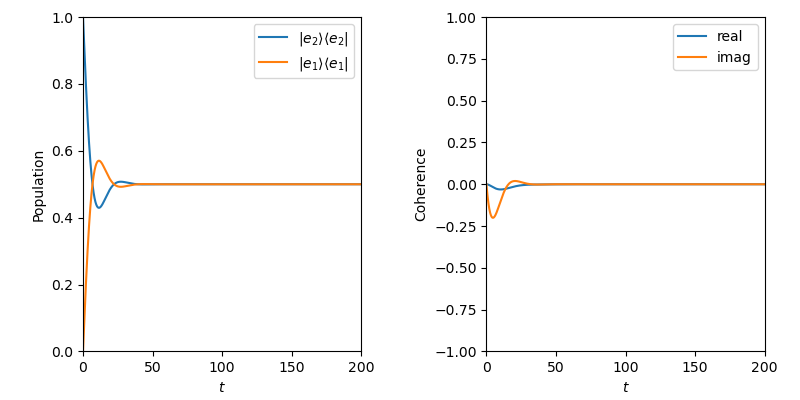

In [50]:
fig1, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(times, np.real(rho_list_diag[0, :]), label=r'$| e_2 \rangle \langle e_2 |$')
ax1.plot(times, np.real(rho_list_diag[3, :]), label=r'$| e_1 \rangle \langle e_1 |$')
ax1.set_xlim(0, times[-1]); ax1.set_ylim(0, 1); ax1.set_xlabel(r'$t$'); ax1.set_ylabel('Population'); ax1.legend()
ax2.plot(times, np.real(rho_list_diag[1, :]), label='real')
ax2.plot(times, np.imag(rho_list_diag[1, :]), label='imag')
ax2.set_xlim(0, times[-1]); ax2.set_ylim(-1, 1); ax2.set_xlabel(r'$t$'); ax2.set_ylabel('Coherence'); ax2.legend()
fig1.tight_layout(); fig1.set_size_inches(8, 4); fig1.set_dpi(100)
plt.show()


In [24]:
array_to_latex(V)

<IPython.core.display.Math object>

In [25]:
array_to_latex(W)

<IPython.core.display.Math object>

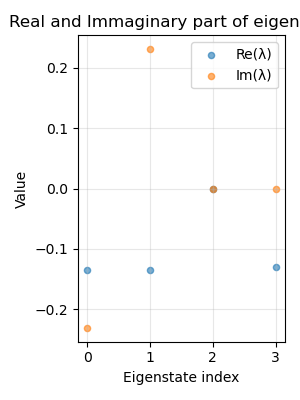

In [26]:
#  Plot of the eigenvalues with separated real and immaginary part
fig2, ax = plt.subplots(figsize=(3,4))
idx = np.arange(len(W))
ax.scatter(idx, W.real, alpha=0.6, s=20, label='Re(λ)')
ax.scatter(idx, W.imag, alpha=0.6, s=20, label='Im(λ)')
ax.set_xlabel('Eigenstate index')
ax.set_ylabel('Value')
ax.set_title('Real and Immaginary part of eigenvalues')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Collisional Method
### Quantum Jump / Monte Carlo limit
The goal is to reproduce the Lindbald dynamic seen above using a Collsional Model, that gives us a trajectory of evolution of a single state of the density matrix $ \ket{\Psi_k} $ rappresentig a qubit. By repeting the dynamic several times it's possibile to recrate the Linbald evolution of the density matrix.
Different unravelling of the $ \rho (t) $ can be achieved by using different Collsional Hamiltonian. First we will reproduce the so called "Quantum Jump" or "Monte Carlo" imit, in which essentialy the states stochastically jumps between the states $ \ket{0} $ and $ \ket{1} $ with a small probability to move to $ \ket{1} $. <br> 
The associated Hamiltonian acting on the System-Ancilla states is:
$$ \mathcal{H}_{CM} = \mathcal{H}_{exc} \otimes \mathbb{I}^{\otimes N} + \mathcal{H}_{collision} $$ 
$$ = \sum_{j=1}^{N} {\frac{\varepsilon_j}{2} \sigma_{z}^{j} \otimes \mathbb{I}^{\otimes N} } + \sum_{\langle j,j' \rangle} {\frac{V_{j,j'}}{2} \left( \sigma_{x}^{j}\sigma_{x}^{j'} \otimes \mathbb{I}^{\otimes N} + \sigma_{y}^{j}\sigma_{y}^{j'} \otimes \mathbb{I}^{\otimes N} \right)} + \sum_{j=1}^{N}{c_j \sigma_{z}^{j} \otimes \sigma_{x}^{a_j}} $$
where $ \sigma_{\alpha}^j = \mathbb{I}^{\otimes j-1} \otimes \sigma_{\alpha} \otimes \mathbb{I}^{\otimes N-j}  $ .<br>
Let's first define the Hamiltonian $ \mathcal{H}_{CM} $ using a single ancilla $ a_j $ for every $ j $ site of the system. Considering the complete system, with both ground and excited states for every site; the associated Hilbert space has dimension equal to : $ dim = 2^N \times 2^N = 2^{2N}  $ and the Hamiltonian takes the form :

In [28]:
# System's Parameters
N_site = 2              # Number of sites
V_pot = 1.0           # Hopping Potential
E = 1.5 + np.random.randn(N_site)*0.1     #random inizialization of the system energies

# Time Evolution Parameters
dt = 0.001          # Time step
tf = 25.0          # Final Time
steps = int(tf / dt) # Number of steps
times = np.linspace(0, tf, steps)

# Dephasing Parameter (come in MATLAB)
g_deph = 0.5       # Gamma rate
# Scaling for the collsional algorithm c = sqrt(gamma / 4dt)
c_CM = np.sqrt(g_deph / (4 * dt)) 
c_list = [c_CM, c_CM] # same Coupling for the 2 sites

array_to_latex(E)

# Base: |00>, |10>, |01>, |11>
H_site, H_coll, H_CM_complete = hamiltonian_N_ancillas(N_site, E, V_pot, c_list, method="complete")

array_to_latex(H_site.full(), array_name=r'\mathcal{H_site}')

array_to_latex(H_CM_complete.full(), array_name=r'\mathcal{H_CM}')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

We could consider only the excited states between which the exciton transfer takes place and again an ancilla for every site. In this case the Hilbert space has $ dim = N \times 2^N $

In [52]:
H_exc, H_coll, H_CM_exc = hamiltonian_N_ancillas(N_site, E, V_pot, c_list, method="excited")    # DA RIVEDERE
array_to_latex(H_CM_exc.full(), array_name=r'\mathcal{H}_{CM exc}')

<IPython.core.display.Math object>

Let's focus on the Interaction Hamiltonian and how it acts on an already enatgled system-ancilla states $ \ket{\Psi} = \ket{\Psi_S} \otimes \ket{0_a} $ <br>
The evolution operator based on $ \mathcal{H}_{collsional} $ is : $$ U_{collsional} = \exp \left(-i c_j \sigma_{z}^{j} \otimes \sigma_{x}^{a_j} \Delta t\right) = \cos \left(c_j \Delta t \right) \mathbb{I}^j \otimes \mathbb{I}^a - i \sin \left(c_j \Delta t \right) \sigma_{z}^{j} \otimes \sigma_{x}^{a_j} $$
And applied to $ \ket{\Psi} $ gives:
$$ \begin{align} 
\ket{\Psi'} &= \cos \left(c_j \Delta t \right) \mathbb{I}^j \otimes \mathbb{I}^a \ket{\Psi} - i \sin \left(c_j \Delta t \right) \sigma_{z}^{j} \otimes \sigma_{x}^{a} \ket{\Psi} \\
&= \cos \left(c_j \Delta t \right) \ket{\Psi_S} \otimes \ket{0_a} - i \sin \left(c_j \Delta t \right) \sigma_{z}^{j} \ket{\Psi_S} \otimes \sigma_{x}^{a} \ket{0_a} \\
&= \cos \left(c_j \Delta t \right) \ket{\Psi_S} \otimes \ket{0_a} - i \sin \left(c_j \Delta t \right) \sigma_{z}^{j} \ket{\Psi_S} \otimes \ket{1_a}
\end{align} $$
By measuring the Ancilla's state we can deduce if we had an avoided collision $ \ket{0_a} $ or an occurred collision $ \ket{1_a} $, which imples the application to the system of $ \sigma_{z}^{j} \ket{\Psi_S} $ which introduce a flip in the phase of the interacting site, with a probability of $ \left| {\sin \left(c_j \Delta t \right)} \right|^2  $, which contributes to the site dephasing process, helping the excitonic tranport (ENAQT - Enviroment Assisted Quantum Transport). <br>
Measuring repeted time $ s $ the Ancilla states correspond on tracing its states out, so that we could rebuild the density matrix as 
$$ \rho_S = \left| c_0 \right| ^2 \ket{\Psi_{0,S}}\bra{\Psi_{0,S}} + \left| c_1 \right|^2 \ket{\Psi_{1,S}}\bra{\Psi_{1,S}} $$ where $ c_0 \propto \cos \left(c_j \Delta t \right)  $ and $ c_1 \propto \sin \left(c_j \Delta t \right) $ <br>

Now we can procede in two different ways:
<ul>
    <li> Evolution of the $ \rho (t) $ with $ U(t) $ and $ U(t)^{\dagger} $; than we trace out the ancilla subsystem with a partial trace over its degree of freedom, in order to get back the average evolution of the system, which gaves a trajectory that reproduces the Lindblad ME. This proves that the Collisional Method gives the same evolution of a Lindblad ME.<br>
        <br>
    <li> Evolution of the only $ \ket{\Psi_{\mathcal{S}}} $ with $ U(t) $ and then the measure on the Ancilla, in order to apply the $ \sigma_z^s $ to the system's state or don't do anything, i.e. apply $ \mathbb{I}^s $. In a Quantistic Computer that can handle the sovrapposition of the ground and excited state of the ancilla, we can just apply the $  U(t) $ build on the $ H_{CM} $ we had already defined. <br> 
        In a Classical Computer we have to simulate the collision with the Ancilla (so that we never pass in a composed state $ \ket{\Psi_{\mathcal{S}}} \otimes \ket{\mathcal{a}} $); this could be done by extracting a random number from a distriubution that replicates the probability given by $ \left| \sin{(c_1 \Delta t)} \right|^2 $, than if the condition in respected it means that an effective collsion has occured and so the ancilla is in the state $ \ket{1_a} $ and so we apply $ \sigma_z^s $ to the system's state; if is not we don't modify the system's state. <br>
        In this way we repoduce a stochastic evolution oh the $ \ket{\Psi_{\mathcal{S}}} $, i.e. a single random trajectory; if we generate different trajectories and the mediate over them $ \overline{\ket{\Psi_{\mathcal{S}}} \bra{\Psi_{\mathcal{S}}}} $ we can rebuild the evolution of the density matrix obtained with the Linblad ME
</ul> 
<br> Let's first focus on the <u>evolution of the $ \rho (t) $ with $ U(t) $ and $ U(t)^{\dagger} $, with then the partial trace on the Ancilla</u>:

In [31]:
#initial wave function and density matrix
#system
psi_sys_initial = tensor(basis(2, 0), basis(2, 1)) # I set the population only in site 2
rho_sys = ket2dm(psi_sys_initial)
#array_to_latex(psi_sys_init.full())
#array_to_latex(rho_sys.full())

#ancilla
rho_anc_single = ket2dm(basis(2, 0)) # Pure state |0><0| for a singe ancilla
rho_anc_all = tensor([rho_anc_single for _ in range(N_site)]) #for N ancilla
#array_to_latex(rho_anc_single.full())
#array_to_latex(rho_anc_all.full())

In [32]:
# Hamiltonian & U
H_site, H_coll, H_tot = hamiltonian_N_ancillas(N_site, E, V_pot, c_list, method="complete")
U_tot = evolution_operator(H_tot, dt, backend='qutip', method='expm')   #calculated only 1 time out of the cycle
#array_to_latex(H_site.full())

In [33]:
# Projector for the extraction from the rho
P0 = (identity(2) + sigmaz()) / 2  # projector on |0>
P1 = (identity(2) - sigmaz()) / 2  # projector su |1>

P_00 = tensor(P0, P0) # |00><00|
P_01 = tensor(P0, P1) # |01><01|
P_10 = tensor(P1, P0) # |10><10|
P_11 = tensor(P1, P1) # |11><11|

# Array to store the results of the evolution dimension time_step x 1
pops_1 = [] #population on site 1
pops_2 = [] #population on site 2

#initial state
pops_1.append(expect(P_10, rho_sys))
pops_2.append(expect(P_01, rho_sys)) 
 

# Time Evolution
for t in range(len(times)):

    # 1 : expansion in the system-ancilla space by tensor product
    rho_tot = tensor(rho_sys, rho_anc_all)   # I always use ancillas in their initial state! already resetted 
    
    # 2 : Unitary evolution of the total rho
    rho_tot = U_tot * rho_tot * U_tot.dag()
    
    # 3 : Partial Trace on the ancilla's degree of freedom
    rho_sys = rho_tot.ptrace([0,1]) 

    # 4 : Store the result of the population
    pops_1.append(expect(P_10, rho_sys))
    pops_2.append(expect(P_01, rho_sys)) 
   

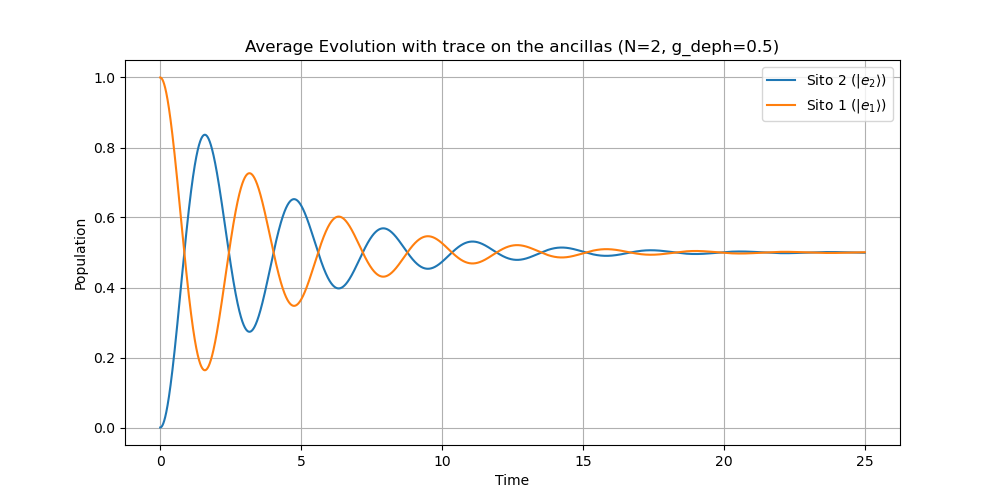

In [34]:
# Plot
times_plot = np.linspace(0, tf + dt, steps + 1) # time for the plot

fig3, ax = plt.subplots(figsize=(10, 5))

ax.plot(times_plot, pops_1, label=r'Sito 2 ($|e_2\rangle$)')
ax.plot(times_plot, pops_2, label=r'Sito 1 ($|e_1\rangle$)')

ax.set_xlabel('Time')
ax.set_ylabel('Population')
ax.set_title( f'Average Evolution with trace on the ancillas (N={N_site}, g_deph={g_deph})')
ax.legend()
ax.grid(True)

plt.show()

In [35]:
#initial wave function and density matrix
#system
psi_sys_initial = tensor(basis(2, 0), basis(2, 1)) # I set the population only in site 2
rho_sys = ket2dm(psi_sys_initial)

#ancilla
rho_anc_single = ket2dm(basis(2, 0)) # Pure state |0><0| for a singe ancilla
rho_anc_all = tensor([rho_anc_single for _ in range(N_site)]) #for N ancilla

In [36]:
# Hamiltonian & U
H_site, H_coll, H_tot = hamiltonian_N_ancillas(N_site, E, V_pot, c_list, method="complete")
U_tot, U_diag, w, V = evolution_operator(H_tot, dt, backend='numpy', method='diagonalization') #calculated only 1 time out of the cycle
#array_to_latex(H_site.full())
U_tot = Qobj(U_tot, dims=H_tot.dims); U_diag = Qobj(U_diag, dims=H_tot.dims); U_diag_dag = U_diag.dag(); V = Qobj(V, dims=H_tot.dims); V_dag = V.dag() 

In [37]:
# Projector for the extraction from the rho
P0 = (identity(2) + sigmaz()) / 2  # projector on |0>
P1 = (identity(2) - sigmaz()) / 2  # projector su |1>

P_00 = tensor(P0, P0) # |00><00|
P_01 = tensor(P0, P1) # |01><01|
P_10 = tensor(P1, P0) # |10><10|
P_11 = tensor(P1, P1) # |11><11|

In [38]:
# Array to store the results of the evolution dimension time_step x 1
pops_1 = [] #population on site 1
pops_2 = [] #population on site 2

#initial state
pops_1.append(expect(P_10, rho_sys))
pops_2.append(expect(P_01, rho_sys)) 

# Time Evolution
for t in range (len(times)):

    # 1 : expansion in the system-ancilla space by tensor product
    rho_tot = tensor(rho_sys, rho_anc_all)   # I always use ancillas in their initial state! already resetted 
    rho_diag = V_dag * rho_tot * V  #diagonal form for the evolution 
    
    # 2 : Unitary evolution of the total rho
    rho_diag = U_diag * rho_diag * U_diag_dag
    rho_tot = V * rho_diag * V_dag
    
    # 3 : Partial Trace on the ancilla's degree of freedom
    rho_sys = rho_tot.ptrace([0,1]) 

    # 4 : Store the result of the population
    pops_1.append(expect(P_10, rho_sys))
    pops_2.append(expect(P_01, rho_sys)) 

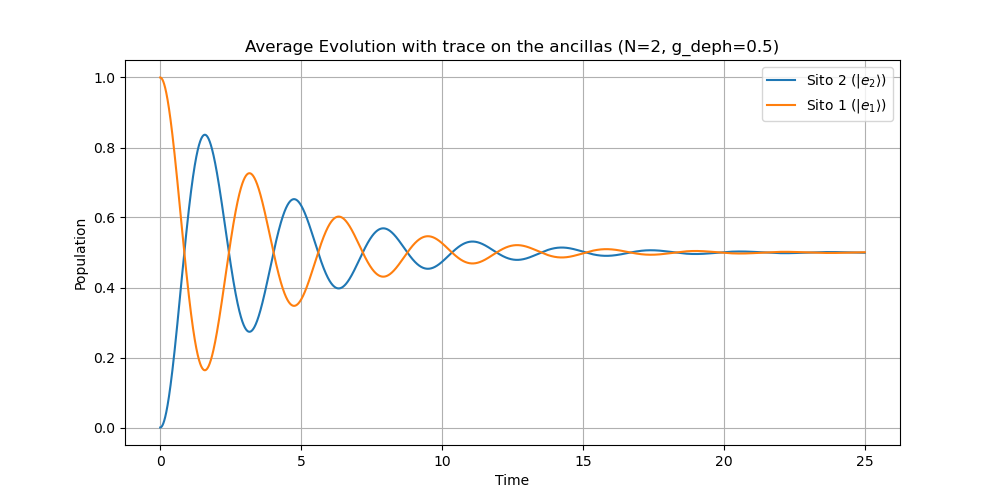

In [39]:
# Plot
times_plot = np.linspace(0, tf + dt, steps + 1) # time for the plot

fig4, ax = plt.subplots(figsize=(10,5))
ax.plot(times_plot, pops_1, label=r'Sito 2 ($|e_2\rangle$)')
ax.plot(times_plot, pops_2, label=r'Sito 1 ($|e_1\rangle$)')
ax.set_xlabel('Time')
ax.set_ylabel('Population')
ax.set_title(f'Average Evolution with trace on the ancillas (N={N_site}, g_deph={g_deph})')
ax.legend()
ax.grid(True)
plt.show()

Now we work on the <u> Evolution of the only $ \ket{\Psi_{\mathcal{S}}} $ with $ U(t) $ and then the measure on the Ancilla </u>. We will: 
<ul>
    1) Apply the unitary evolution due to only $ H_{site} $ and the hopping potential $ V $ for a disctrete time step $ \Delta t $ <br>
    2) Extract a random number between 0 and 1 for every system's site <br>
    3) If the extracted number for the single site is lower than $ \left| \sin{(c_i \Delta t)} \right| $ we apply the $ \sigma_z $ operator to that site <br>
    4) Record the site popolutation at that time, than restart the algorithm
</ul> <br>
In order to extract an average dynamic we will run the algorithm different times for generate different trajectoryes

In [40]:
# Hamiltonian & System Wave Function
H_system = system_Hamiltonian(N_site, E, V_pot, mode="complete")
array_to_latex(H_system)
U_site, U_diag_site, w, V = evolution_operator(H_system, dt, backend='qutip', method='diagonalization', hermitian=True)
U_site.dims = H_site.dims 

psi_sys_initial = tensor(basis(2, 0), basis(2, 1)) # I set the population only in site 2
array_to_latex(psi_sys_initial.full(), real=True)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [41]:
# Evolution of the Wave Function
jump_probabilities = [np.sin(c * dt)**2 for c in c_list]   #probability to apply sigmaz to psi
N_traj = 100  #number of trajectories repeted
pop_N_traj = np.zeros((N_site, steps, N_traj))  #array to store the population of every site at every step of evolution for every trajectories

# Costruction of the sigmaz operator for every site
Sz_ops = []
for idx in range(N_site):
    ops = [qeye(2) for _ in range(N_site)]
    ops[idx] = sigmaz()  # Sigmaz solo sul sito idx
    Sz_op = tensor(ops)
    Sz_ops.append(Sz_op)
    
# Inizialization
pop_site_1_initial = expect(P_10, psi_sys_initial)
pop_site_2_initial = expect(P_01, psi_sys_initial)

pop_N_traj[0,0,:] = pop_site_1_initial
pop_N_traj[1,0,:] = pop_site_2_initial

# Evolution for different Trajectories 
for traj in range (N_traj):

    psi = psi_sys_initial   #reset initial wf |01>

    # Evolution in Time (starting after 1st timestep)
    for step in range(1, len(times)):
        
        psi = U_site * psi   # Evolution of wf with H_site
        
        #Defining the condition of the Monte Carlo - Jump for every site
        for site_index in range(N_site):
            r_site = np.random.rand() # Random number between 0 & 1
            
            if r_site < jump_probabilities[site_index]:
                psi = Sz_ops[site_index] * psi   # apply Sigmaz 
                psi = psi / psi.norm()   #{no renormalization, Sigmaz unitary}
       
        pop_site_1 = expect(P_10, psi)
        pop_site_2 = expect(P_01, psi)

        pop_N_traj[0, step, traj] = pop_site_1
        pop_N_traj[1, step, traj] = pop_site_2

# Average value of different trajectories
average_pop = np.mean(pop_N_traj, axis=2)    

In [42]:
# Isolated system
pop_N_traj_isolated = np.zeros((N_site, steps, N_traj))
# Inizialization
pop_site_1_initial = expect(P_10, psi_sys_initial)
pop_site_2_initial = expect(P_01, psi_sys_initial)

pop_N_traj_isolated [0,0,:] = pop_site_1_initial
pop_N_traj_isolated [1,0,:] = pop_site_2_initial

# Evolution for different Trajectories 
for traj in range (N_traj):

    psi = psi_sys_initial   #reset initial wf |01>

    # Evolution in Time (starting after 1st timestep)
    for step in range(1, len(times)):
        
        psi = U_site * psi   # Evolution of wf with H_site
               
        pop_site_1 = expect(P_10, psi)
        pop_site_2 = expect(P_01, psi)

        pop_N_traj_isolated[0, step, traj] = pop_site_1
        pop_N_traj_isolated [1, step, traj] = pop_site_2

# Average value of different trajectories
average_pop_isolated = np.mean(pop_N_traj_isolated, axis=2)  

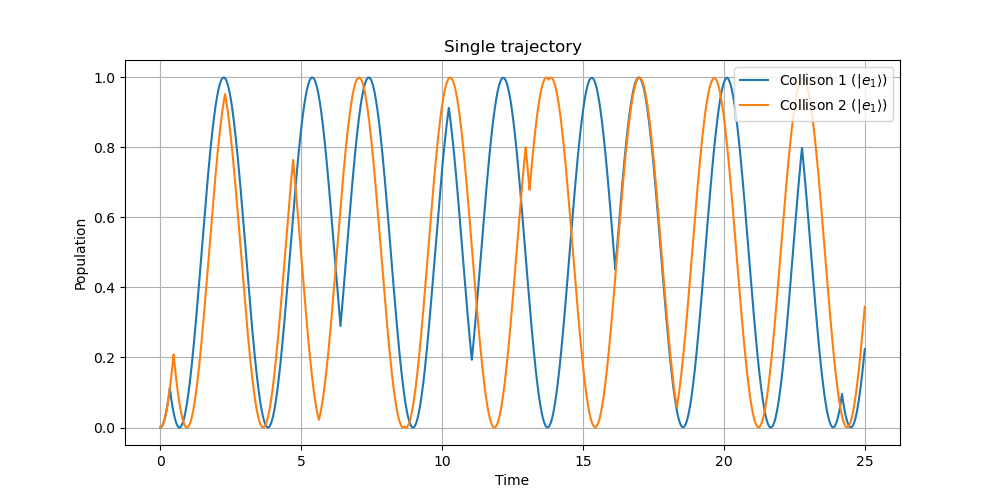

In [43]:
times_plot = np.linspace(0, tf + dt, steps) # time for the plot

fig7, ax = plt.subplots(figsize=(10, 5))

ax.plot(times_plot, pop_N_traj[0, :, 1], label=r'Collison 1 ($|e_1\rangle$)')
ax.plot(times_plot, pop_N_traj[0, :, 55], label=r'Collison 2 ($|e_1\rangle$)')
#ax.plot(times_plot, pop_N_traj_isolated[1, :, 5], label=r'Isolated ($|e_2\rangle$)')

ax.set_xlabel('Time')
ax.set_ylabel('Population')
ax.set_title( 'Single trajectory')
ax.legend()
ax.grid(True)

plt.show()

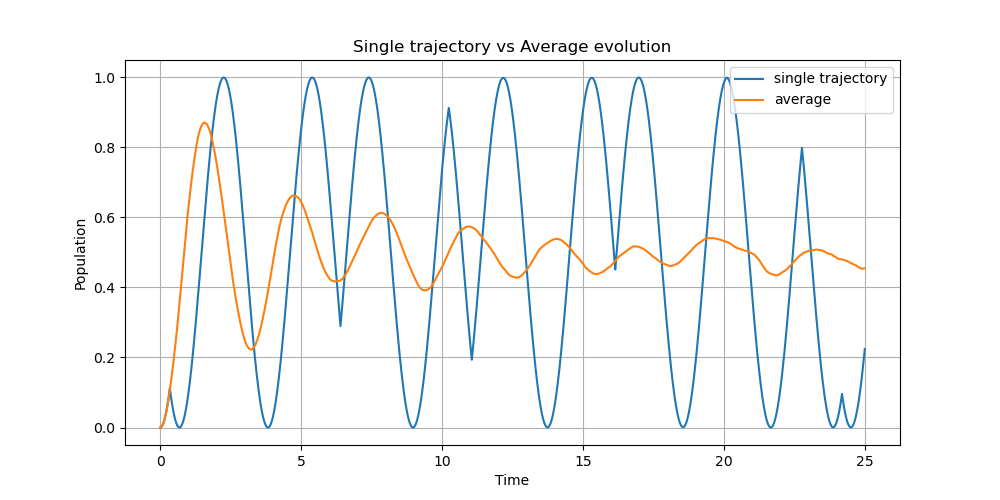

In [52]:
fig7, ax = plt.subplots(figsize=(10, 5))

ax.plot(times_plot, pop_N_traj[0, :, 1], label=r'single trajectory')
ax.plot(times_plot, average_pop[0, :], label=r'average')

ax.set_xlabel('Time')
ax.set_ylabel('Population')
ax.set_title( 'Single trajectory vs Average evolution')
ax.legend()
ax.grid(True)

plt.show()

## LINDBLAD

In [48]:
V_pot=1.0
H = system_Hamiltonian(N_site, E, V_pot, mode="complete")
psi_sys_initial = tensor(basis(2, 0), basis(2, 1)) # I set the population only in site 2
rho = ket2dm(psi_sys_initial)
#Jump Oerator
L_1 = tensor(sigmaz(), qeye(2))
L_2 = tensor(qeye(2), sigmaz())

L_k = [L_1.full(), L_2.full()]

#Rates
gamma = g_deph * 0.25
gamma_k = [gamma, gamma]

Super_L = Liouvillian(H, gamma_k, L_k)
rho_list_diag, V, W = Lindblad_evo(rho, H, gamma_k, L_k, times, method="diagonal", vectorized=False)

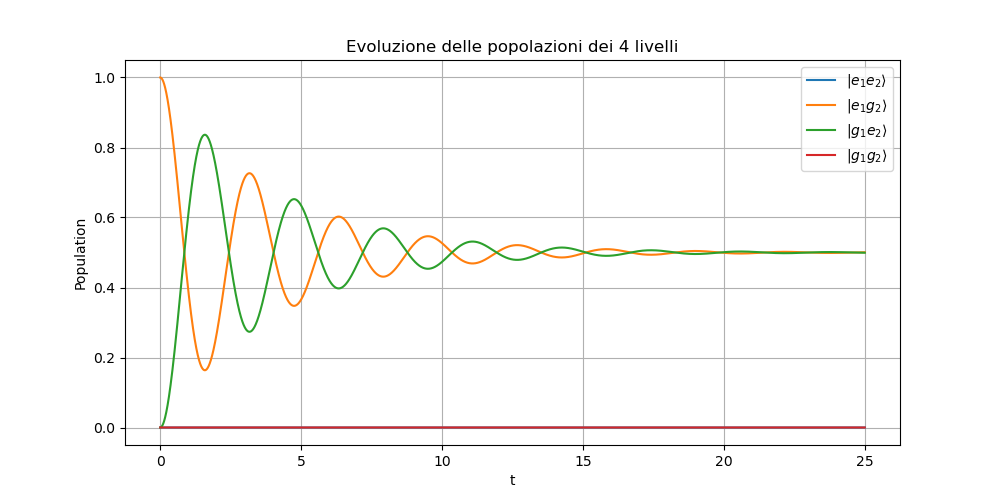

In [49]:
fig5, ax = plt.subplots(figsize=(10,5))
for i, label in enumerate([r'$|e_1e_2\rangle$', r'$|e_1g_2\rangle$', 
                           r'$|g_1e_2\rangle$', r'$|g_1g_2\rangle$']):
    ax.plot(times, np.real(rho_list_diag[:, i, i]), label=label)
    # Nota: [:, i, i] per estrarre l'i-esimo elemento diagonale ad ogni tempo

ax.set_xlabel('t')
ax.set_ylabel('Population')
ax.legend()
ax.grid(True)
ax.set_title('Evoluzione delle popolazioni dei 4 livelli')
plt.show()

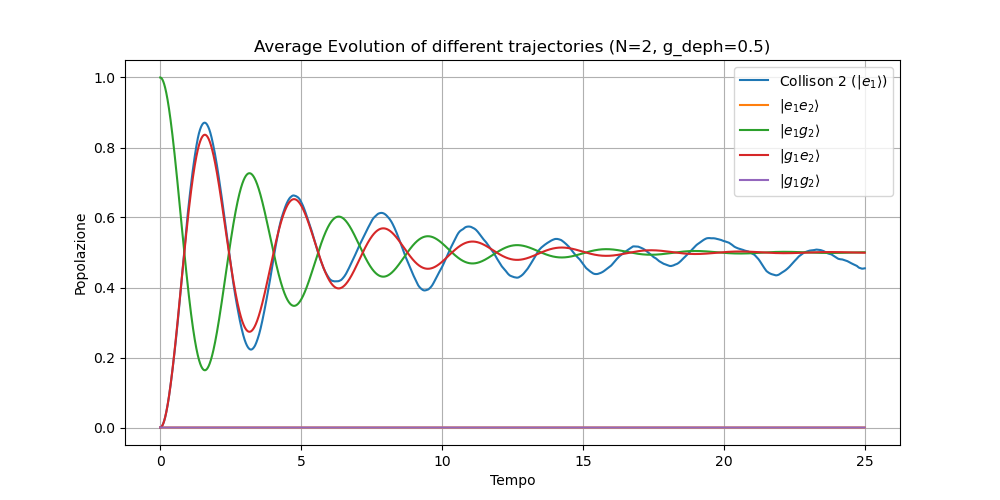

In [51]:

fig6, ax = plt.subplots(figsize=(10,5))
ax.plot(times_plot, average_pop[0, :], label=r'Collison 2 ($|e_1\rangle$)')
for i, label in enumerate([r'$|e_1e_2\rangle$', r'$|e_1g_2\rangle$', 
                           r'$|g_1e_2\rangle$', r'$|g_1g_2\rangle$']):
    ax.plot(times, np.real(rho_list_diag[:, i, i]), label=label)
ax.set_xlabel('Tempo')
ax.set_ylabel('Popolazione')
ax.set_title(f'Average Evolution of different trajectories (N={N_site}, g_deph={g_deph})')
ax.legend()
ax.grid(True)
plt.show()

#### COSE DA FARE: 1)DEFINIRE BENE LE COSTANTI/RATES C 2)PROVARE EVOLUZIONE CON TROTTERIZZAZIONE; 3)RIDEFINIRE H_COLL NEL SOLO SUBSPACE DI ECCITAZIONE